In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import pyref.fitting as fit
import scienceplots
import sigfig
from refnx.analysis import GlobalObjective, Transform

from utils import read_ooc
from utils.helpers.plotting_helper import set_plotting_defaults

set_plotting_defaults()

#  set matplotlib ticks to point inward
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
# plt.rcParams["text.usetex"] = True
# Add ticks to the top and right side of every axis
plt.rcParams["xtick.top"] = True
plt.rcParams["ytick.right"] = True
# Set the grids so that they are dashed
plt.rcParams["grid.linestyle"] = "--"
plt.rcParams["grid.linewidth"] = 0.5
# Ensure grids draw on minor ticks
plt.rcParams["axes.grid.which"] = "both"

In [50]:
from utils import read_fit

fit_results = read_fit("/home/hduva/projects/xrr_notebooks/models/xrr/dft/dft_en_offset_new2.pkl")

<Axes: xlabel='zed / $\\AA$', ylabel='Index of refraction'>

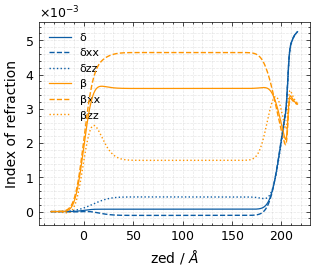

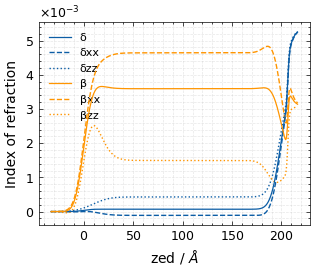

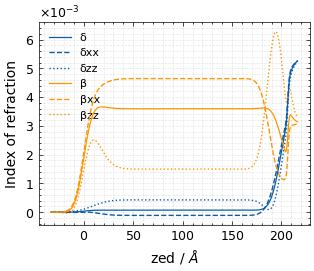

In [51]:
def construct_slab(energy, fit_results, surface=None, bulk=None, interface=None):
    template = fit_results.objectives[-1].model.structure
    for i, layer in enumerate(template):
        layer.sld.energy = energy
        if i == 1 and surface is not None:
            layer.sld.rotation.constraint=None
            layer.sld.rotation.setp(value=surface)
        elif i == 2 and bulk is not None:
            layer.sld.rotation.constraint=None
            layer.sld.rotation.setp(value=bulk)
        elif i == 3 and interface is not None:
            layer.sld.rotation.constraint=None
            layer.sld.rotation.setp(value=interface)

    return template

construct_slab(285, fit_results).plot()
construct_slab(285, fit_results, interface=np.pi/2).plot()
construct_slab(285, fit_results, interface=0).plot()

In [52]:
def q(theta, energy):
    """Calculate q from theta and energy."""
    theta_rad = np.radians(theta)
    # Use broadcasting to create a (len(theta), len(energy)) array
    return (
        4 * np.pi * np.sin(theta_rad[:, np.newaxis]) * energy[np.newaxis, :] / 12398.42
    )

In [68]:
def fixed_angle(
    energies: np.ndarray,
    thetas: np.ndarray,
    interface: float,
    pol: str,
    fit_results=fit_results,
):
    """Calculate reflectivity for a fixed angle scan."""
    q_values = q(thetas, energies)
    reflectivity = np.empty_like(q_values, dtype=float)

    # Loop over energies as model construction is energy-dependent
    for i, e in enumerate(energies):
        model_func = fit.ReflectModel(
            construct_slab(e, fit_results, interface=interface),
            pol=pol,
            energy=e,
        )
        # Calculate for all thetas at once for a given energy
        reflectivity[:, i] = model_func(q_values[:, i])
    return reflectivity


# Define angles and interfaces
theta = np.array(np.linspace(0, 60, 60))
interfaces = np.linspace(0, np.pi / 2, 100)
energies = np.linspace(280, 290, 200)

# Pre-allocate arrays to store s and p polarization data
s_data_all = np.zeros((len(theta), len(interfaces), len(energies)))
p_data_all = np.zeros((len(theta), len(interfaces), len(energies)))

# Loop over interface orientations
for j, itheta in enumerate(interfaces):
    s_data_all[:, j, :] = fixed_angle(
        energies, theta, pol="s", interface=itheta
    )
    p_data_all[:, j, :] = fixed_angle(
        energies, theta, pol="p", interface=itheta
    )

# Calculate the anisotropy ratio from the stored data

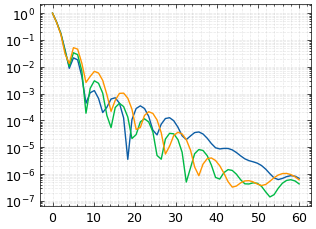

In [69]:
fig, ax = plt.subplots()
ax.plot(theta, p_data_all[:, 0, 100])
ax.plot(theta, p_data_all[:, 49, 100])
ax.plot(theta, p_data_all[:, 99, 100])
ax.set_yscale("log")

In [71]:
p_data_all.shape, s_data_all.shape

((60, 100, 200), (60, 100, 200))

In [81]:
from pathlib import Path

import pandas as pd


def resolve_project_root(start: Path) -> Path:
    """Resolve repository root from a starting directory.

    Parameters
    ----------
    start : Path
        Directory used to begin searching for the repository root.

    Returns
    -------
    Path
        Detected repository root.
    """
    current = start.resolve()
    for candidate in (current, *current.parents):
        if (candidate / ".git").exists() or (candidate / "pyproject.toml").exists():
            return candidate
    return current


project_root = resolve_project_root(Path.cwd())
output_dir = project_root / "notebooks" / "exploration" / "outputs" / "fixed_angle"
output_dir.mkdir(parents=True, exist_ok=True)

n_theta = theta.size
n_interface = interfaces.size
n_energy = energies.size
expected_shape = (n_theta, n_interface, n_energy)
row_count = n_theta * n_interface * n_energy

if s_data_all.shape != expected_shape or p_data_all.shape != expected_shape:
    raise ValueError(
        f"Expected s_data_all and p_data_all shape {expected_shape}, got {s_data_all.shape} and {p_data_all.shape}"
    )

anisotropy_cube = (s_data_all - p_data_all) / (s_data_all + p_data_all + 1e-12)

theta_column = np.repeat(theta, n_interface * n_energy)
interface_column = np.tile(np.repeat(interfaces, n_energy), n_theta)
energy_column = np.tile(energies, n_theta * n_interface)

sim_df = pd.DataFrame(
    {
        "theta_deg": np.round(theta_column, 3),
        "interface_rad": interface_column,
        "energy_ev": energy_column,
        "s_reflectivity": s_data_all.reshape(row_count),
        "p_reflectivity": p_data_all.reshape(row_count),
        "anisotropy_ratio": anisotropy_cube.reshape(row_count),
    }
)

sim_df["interface_deg"] = np.degrees(sim_df["interface_rad"])
sim_df["simulation_id"] = np.arange(sim_df.shape[0], dtype=np.int64)

sim_path = output_dir / "fixed_angle_simulation.parquet"
sim_df.to_parquet(sim_path, index=False)

print(f"saved: {sim_path}")
sim_df

saved: /home/hduva/projects/xrr_notebooks/notebooks/exploration/outputs/fixed_angle/fixed_angle_simulation.parquet


,theta_deg,interface_rad,energy_ev,s_reflectivity,p_reflectivity,anisotropy_ratio,interface_deg,simulation_id
0,0,0.000000,280.000000,1.000000,1.000000e+00,0.000000,0.0,0
1,0,0.000000,280.050251,1.000000,1.000000e+00,0.000000,0.0,1
2,0,0.000000,280.100503,1.000000,1.000000e+00,0.000000,0.0,2
3,0,0.000000,280.150754,1.000000,1.000000e+00,0.000000,0.0,3
4,0,0.000000,280.201005,1.000000,1.000000e+00,0.000000,0.0,4
...,...,...,...,...,...,...,...,...
1199995,60,1.570796,289.798995,0.000001,3.116400e-07,0.616357,90.0,1199995
1199996,60,1.570796,289.849246,0.000001,3.091953e-07,0.616684,90.0,1199996
1199997,60,1.570796,289.899497,0.000001,3.065343e-07,0.617067,90.0,1199997
1199998,60,1.570796,289.949749,0.000001,3.035844e-07,0.617525,90.0,1199998


saved: /home/hduva/projects/xrr_notebooks/notebooks/exploration/outputs/fixed_angle/fixed_angle_sensitivity.parquet


,theta_deg,mean_abs_dsignal_dinterface,peak_abs_dsignal_dinterface,mean_p95_p05_contrast,orientation_to_energy_variance_ratio,mean_abs_dsignal_dinterface_norm,peak_abs_dsignal_dinterface_norm,mean_p95_p05_contrast_norm,orientation_to_energy_variance_ratio_norm,sensitivity_score,sensitivity_rank,theta_label_deg
0,27.458,0.488080,45.806503,0.640604,0.595291,1.000000,1.000000,0.953545,0.441024,0.848642,1,27.458
1,28.475,0.471757,29.674104,0.660379,0.604374,0.966555,0.647814,0.982980,0.447753,0.761276,2,28.475
2,21.356,0.463270,9.236743,0.671813,0.916423,0.949168,0.201647,1.000000,0.678936,0.707438,3,21.356
3,22.373,0.402314,6.723171,0.580089,1.143619,0.824279,0.146773,0.863468,0.847256,0.670444,4,22.373
4,23.390,0.334958,2.252217,0.506575,1.349792,0.686277,0.049168,0.754042,1.000000,0.622372,5,23.390
5,34.576,0.461232,9.827549,0.579395,0.590204,0.944991,0.214545,0.862436,0.437255,0.614807,6,34.576
6,26.441,0.379422,3.972964,0.517379,1.033029,0.777377,0.086734,0.770124,0.765325,0.599890,7,26.441
7,35.593,0.431150,10.315681,0.558515,0.614509,0.883359,0.225201,0.831355,0.455262,0.598794,8,35.593
8,24.407,0.321080,1.658804,0.492615,1.272720,0.657843,0.036213,0.733263,0.942901,0.592555,9,24.407
9,15.254,0.361735,5.778984,0.526919,0.946983,0.741138,0.126161,0.784323,0.701577,0.588300,10,15.254


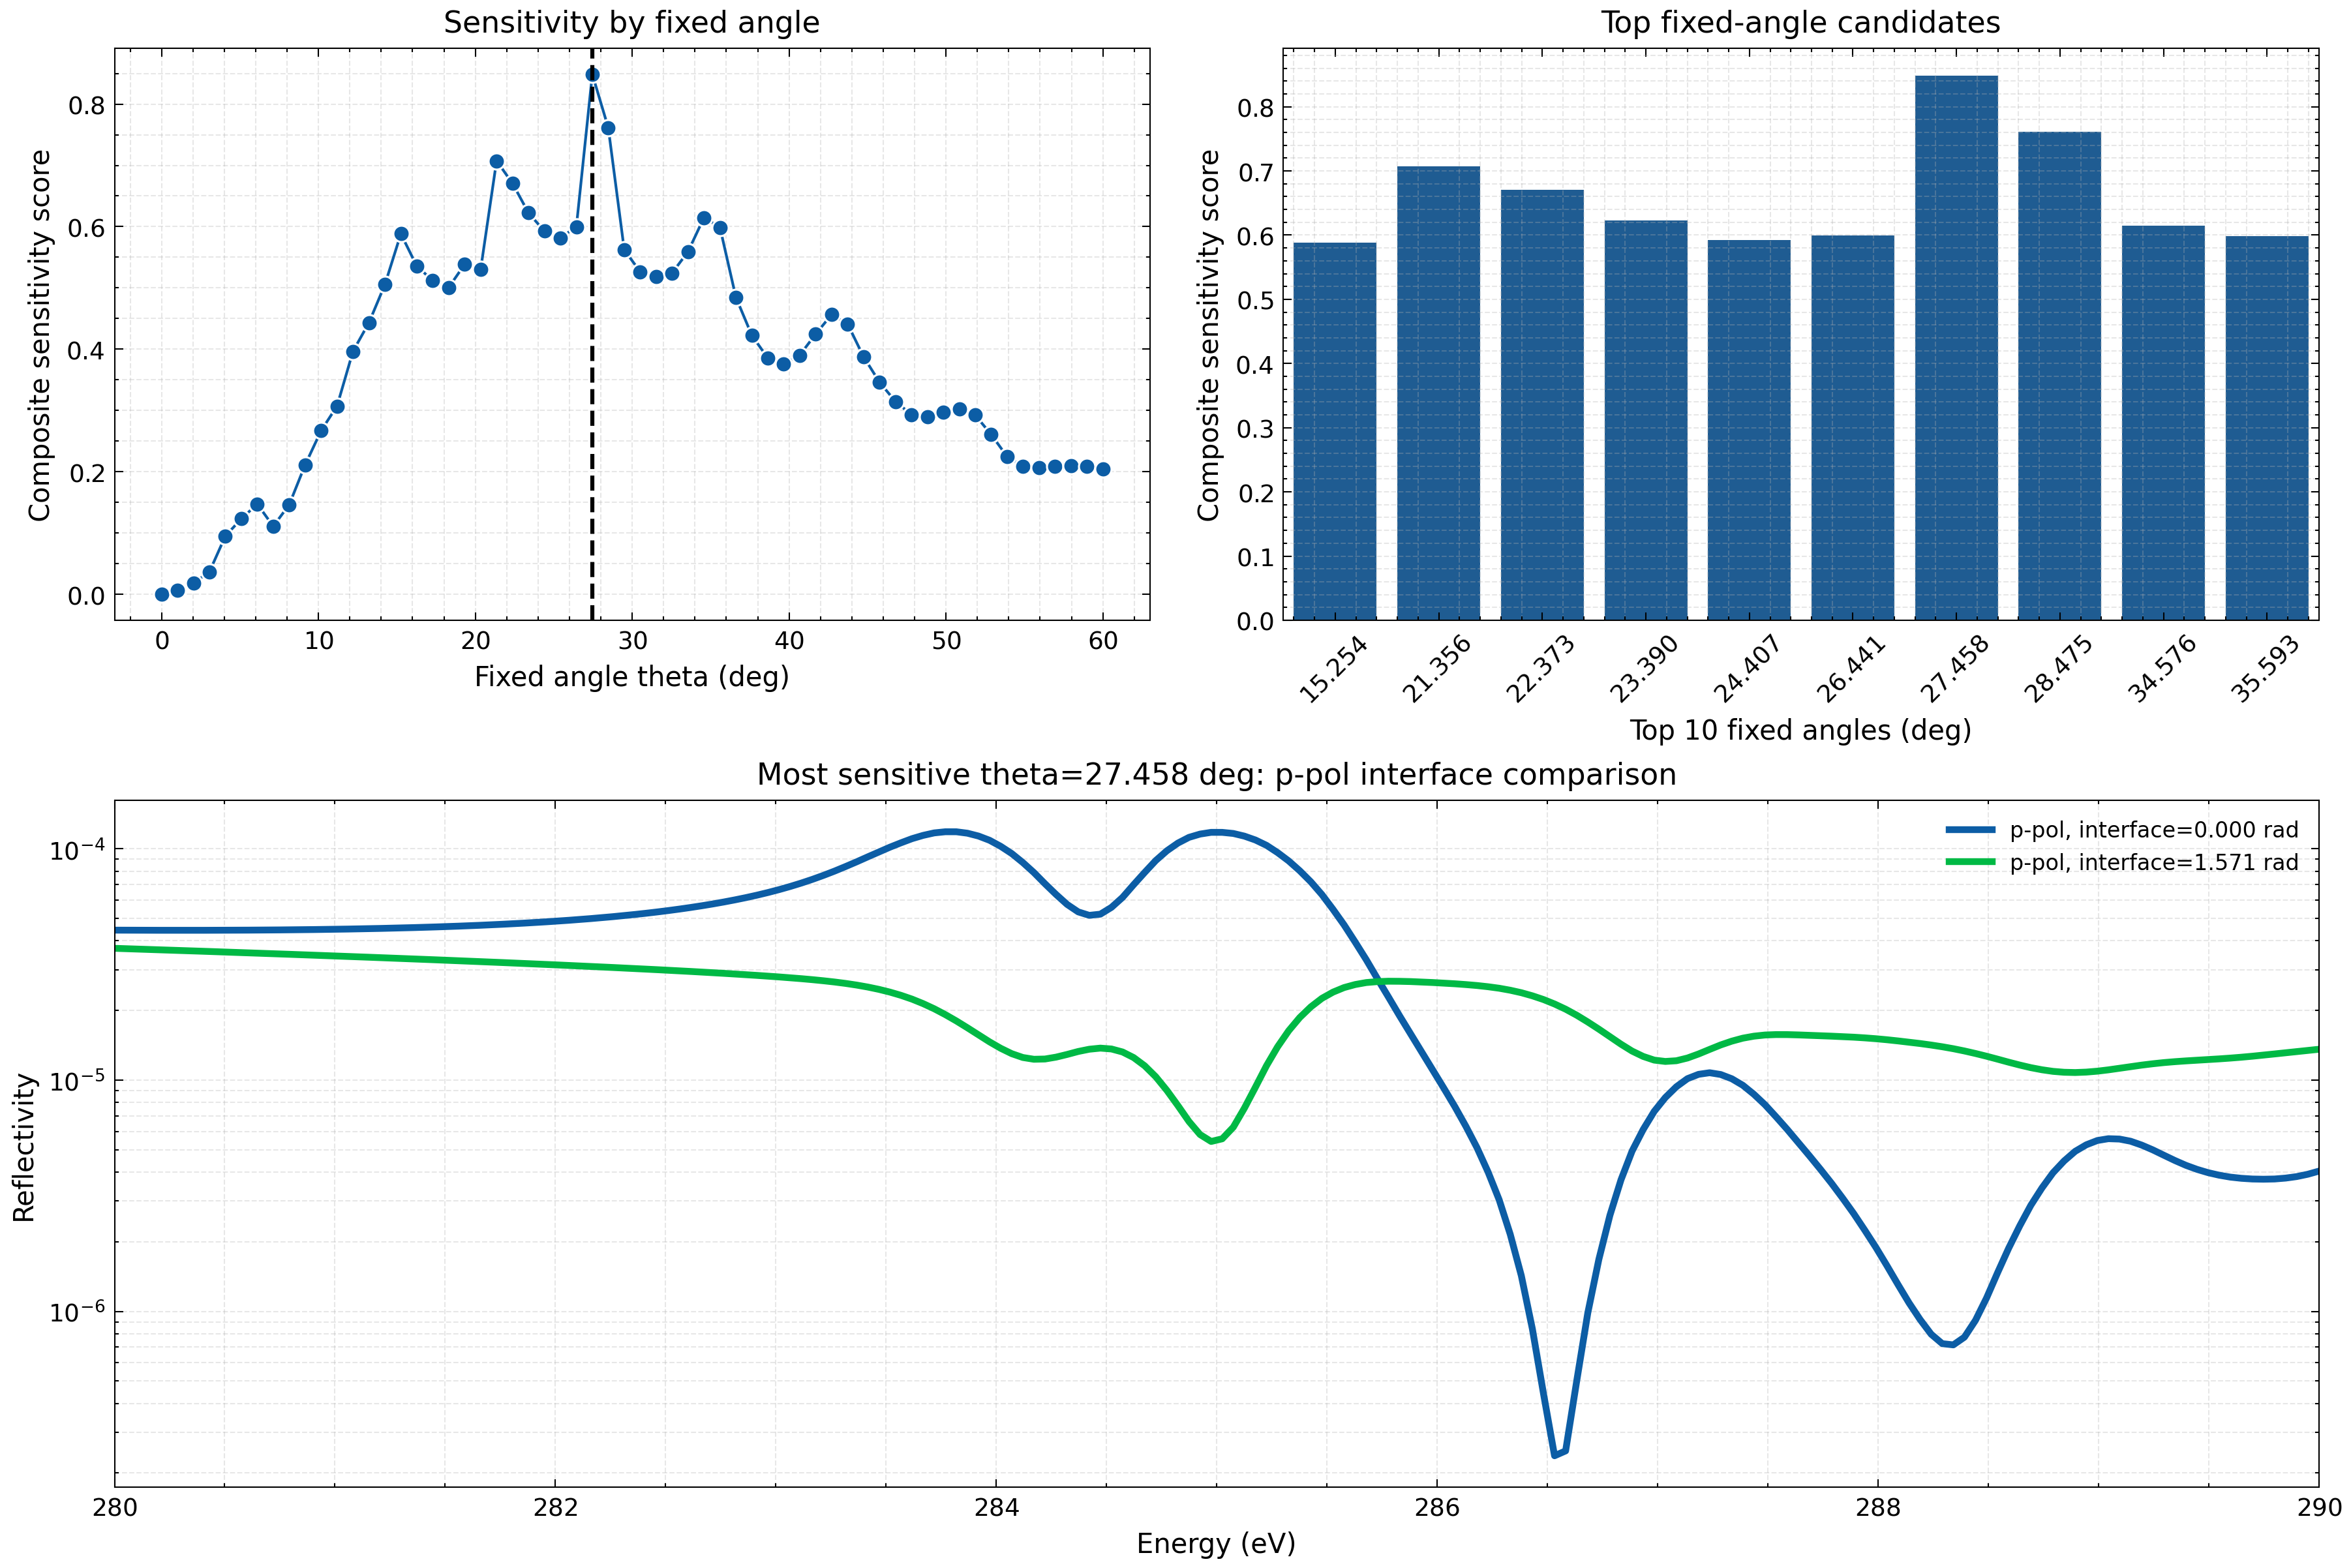

In [86]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.dpi"] = 300

def sensitivity_summary(theta_values: np.ndarray, interface_values: np.ndarray, signal_cube: np.ndarray) -> pd.DataFrame:
    """Compute sensitivity metrics for each fixed angle.

    Parameters
    ----------
    theta_values : np.ndarray
        Fixed-angle grid in degrees.
    interface_values : np.ndarray
        Interface orientation grid in radians.
    signal_cube : np.ndarray
        Signal array with shape (n_theta, n_interface, n_energy).

    Returns
    -------
    pd.DataFrame
        Sensitivity metrics and ranking for each fixed angle.
    """
    interface_gradient = np.gradient(signal_cube, interface_values, axis=1)
    abs_gradient = np.abs(interface_gradient)

    slope_mean = abs_gradient.mean(axis=(1, 2))
    slope_peak = abs_gradient.max(axis=(1, 2))

    contrast = np.percentile(signal_cube, 95, axis=1) - np.percentile(signal_cube, 5, axis=1)
    contrast_mean = contrast.mean(axis=1)

    signal_var = signal_cube.var(axis=1).mean(axis=1)
    energy_var = signal_cube.var(axis=2).mean(axis=1)
    orient_to_energy_ratio = signal_var / (energy_var + 1e-12)

    metrics = pd.DataFrame(
        {
            "theta_deg": np.round(theta_values, 3),
            "mean_abs_dsignal_dinterface": slope_mean,
            "peak_abs_dsignal_dinterface": slope_peak,
            "mean_p95_p05_contrast": contrast_mean,
            "orientation_to_energy_variance_ratio": orient_to_energy_ratio,
        }
    )

    metric_cols = [
        "mean_abs_dsignal_dinterface",
        "peak_abs_dsignal_dinterface",
        "mean_p95_p05_contrast",
        "orientation_to_energy_variance_ratio",
    ]

    for col in metric_cols:
        col_min = metrics[col].min()
        col_span = metrics[col].max() - col_min
        metrics[f"{col}_norm"] = 0.0 if col_span == 0 else (metrics[col] - col_min) / col_span

    norm_cols = [f"{col}_norm" for col in metric_cols]
    metrics["sensitivity_score"] = metrics[norm_cols].mean(axis=1)
    metrics["sensitivity_rank"] = metrics["sensitivity_score"].rank(ascending=False, method="dense").astype(int)
    metrics = metrics.sort_values("sensitivity_score", ascending=False).reset_index(drop=True)
    return metrics


sensitivity_df = sensitivity_summary(theta, interfaces, anisotropy_cube)
sensitivity_df["theta_label_deg"] = sensitivity_df["theta_deg"].map(lambda x: f"{x:.3f}")

sensitivity_path = output_dir / "fixed_angle_sensitivity.parquet"
sensitivity_df.to_parquet(sensitivity_path, index=False)

print(f"saved: {sensitivity_path}")
display(sensitivity_df.head(10))

most_sensitive_theta = float(sensitivity_df.iloc[0]["theta_deg"])
theta_idx = int(np.argmin(np.abs(theta - most_sensitive_theta)))
interface_idx_0 = int(np.argmin(np.abs(interfaces - 0.0)))
interface_idx_pi2 = int(np.argmin(np.abs(interfaces - (np.pi / 2))))

fig = plt.figure(figsize=(12, 8), constrained_layout=True)
grid = fig.add_gridspec(2, 2, height_ratios=[1, 1.2])
ax0 = fig.add_subplot(grid[0, 0])
ax1 = fig.add_subplot(grid[0, 1])
ax2 = fig.add_subplot(grid[1, :])

sns.lineplot(
    data=sensitivity_df.sort_values("theta_deg"),
    x="theta_deg",
    y="sensitivity_score",
    marker="o",
    ax=ax0,
)
ax0.set_xlabel("Fixed angle theta (deg)")
ax0.set_ylabel("Composite sensitivity score")
ax0.set_title("Sensitivity by fixed angle")
ax0.grid(True)
ax0.axvline(theta[theta_idx], color="k", linestyle="--", linewidth=1.5)

top10 = sensitivity_df.head(10).sort_values("theta_deg")
sns.barplot(
    data=top10,
    x="theta_label_deg",
    y="sensitivity_score",
    ax=ax1,
)
ax1.set_xlabel("Top 10 fixed angles (deg)")
ax1.set_ylabel("Composite sensitivity score")
ax1.set_title("Top fixed-angle candidates")
ax1.tick_params(axis="x", rotation=45)

ax2.plot(
    energies,
    p_data_all[theta_idx, interface_idx_0, :],
    lw=2.5,
    label="p-pol, interface=0.000 rad",
)
ax2.plot(
    energies,
    p_data_all[theta_idx, interface_idx_pi2, :],
    lw=2.5,
    label="p-pol, interface=1.571 rad",
)
ax2.set_xlabel("Energy (eV)")
ax2.set_ylabel("Reflectivity")
ax2.set_title(f"Most sensitive theta={theta[theta_idx]:.3f} deg: p-pol interface comparison")
ax2.set_yscale("log")
ax2.set_xlim(energies.min(), energies.max())
ax2.grid(True, which="both")
ax2.legend()

plt.show()

/home/hduva/projects/xrr_notebooks/.venv/lib/python3.12/site-packages/SALib/analyze/sobol.py:141: RuntimeWarning: invalid value encountered in divide
  Y = (Y - Y.mean()) / Y.std()


saved: /home/hduva/projects/xrr_notebooks/notebooks/exploration/outputs/fixed_angle/fixed_angle_sensitivity_salib.parquet


,theta_deg,morris_mu_star_interface,morris_sigma_interface,morris_mu_star_energy,sobol_s1_interface,sobol_st_interface,sobol_s1_energy,sobol_st_energy,rank_by_sobol_st_interface,theta_label_deg
0,23.390,0.519013,0.539008,0.923939,0.259577,0.957826,-0.009621,0.720942,1,23.390
1,24.407,0.465023,0.486223,0.692953,0.264079,0.920481,0.055790,0.729583,2,24.407
2,25.424,0.412739,0.447162,0.511519,0.254269,0.909200,0.091680,0.755126,3,25.424
3,22.373,0.595408,0.618321,1.043382,0.185260,0.904100,0.072727,0.788364,4,22.373
4,19.322,0.221435,0.251826,0.434505,0.357838,0.887320,0.129881,0.667111,5,19.322
5,26.441,0.436475,0.563329,0.474678,0.187064,0.882128,0.149768,0.829241,6,26.441
6,32.542,0.434967,0.505053,0.605843,0.104708,0.881302,0.121161,0.895454,7,32.542
7,31.525,0.480740,0.519460,0.701219,0.090924,0.880211,0.105625,0.898712,8,31.525
8,13.220,0.062294,0.071071,0.635931,0.289192,0.857401,0.154163,0.696702,9,13.220
9,30.508,0.525264,0.558829,0.820887,0.055675,0.853205,0.128225,0.922096,10,30.508


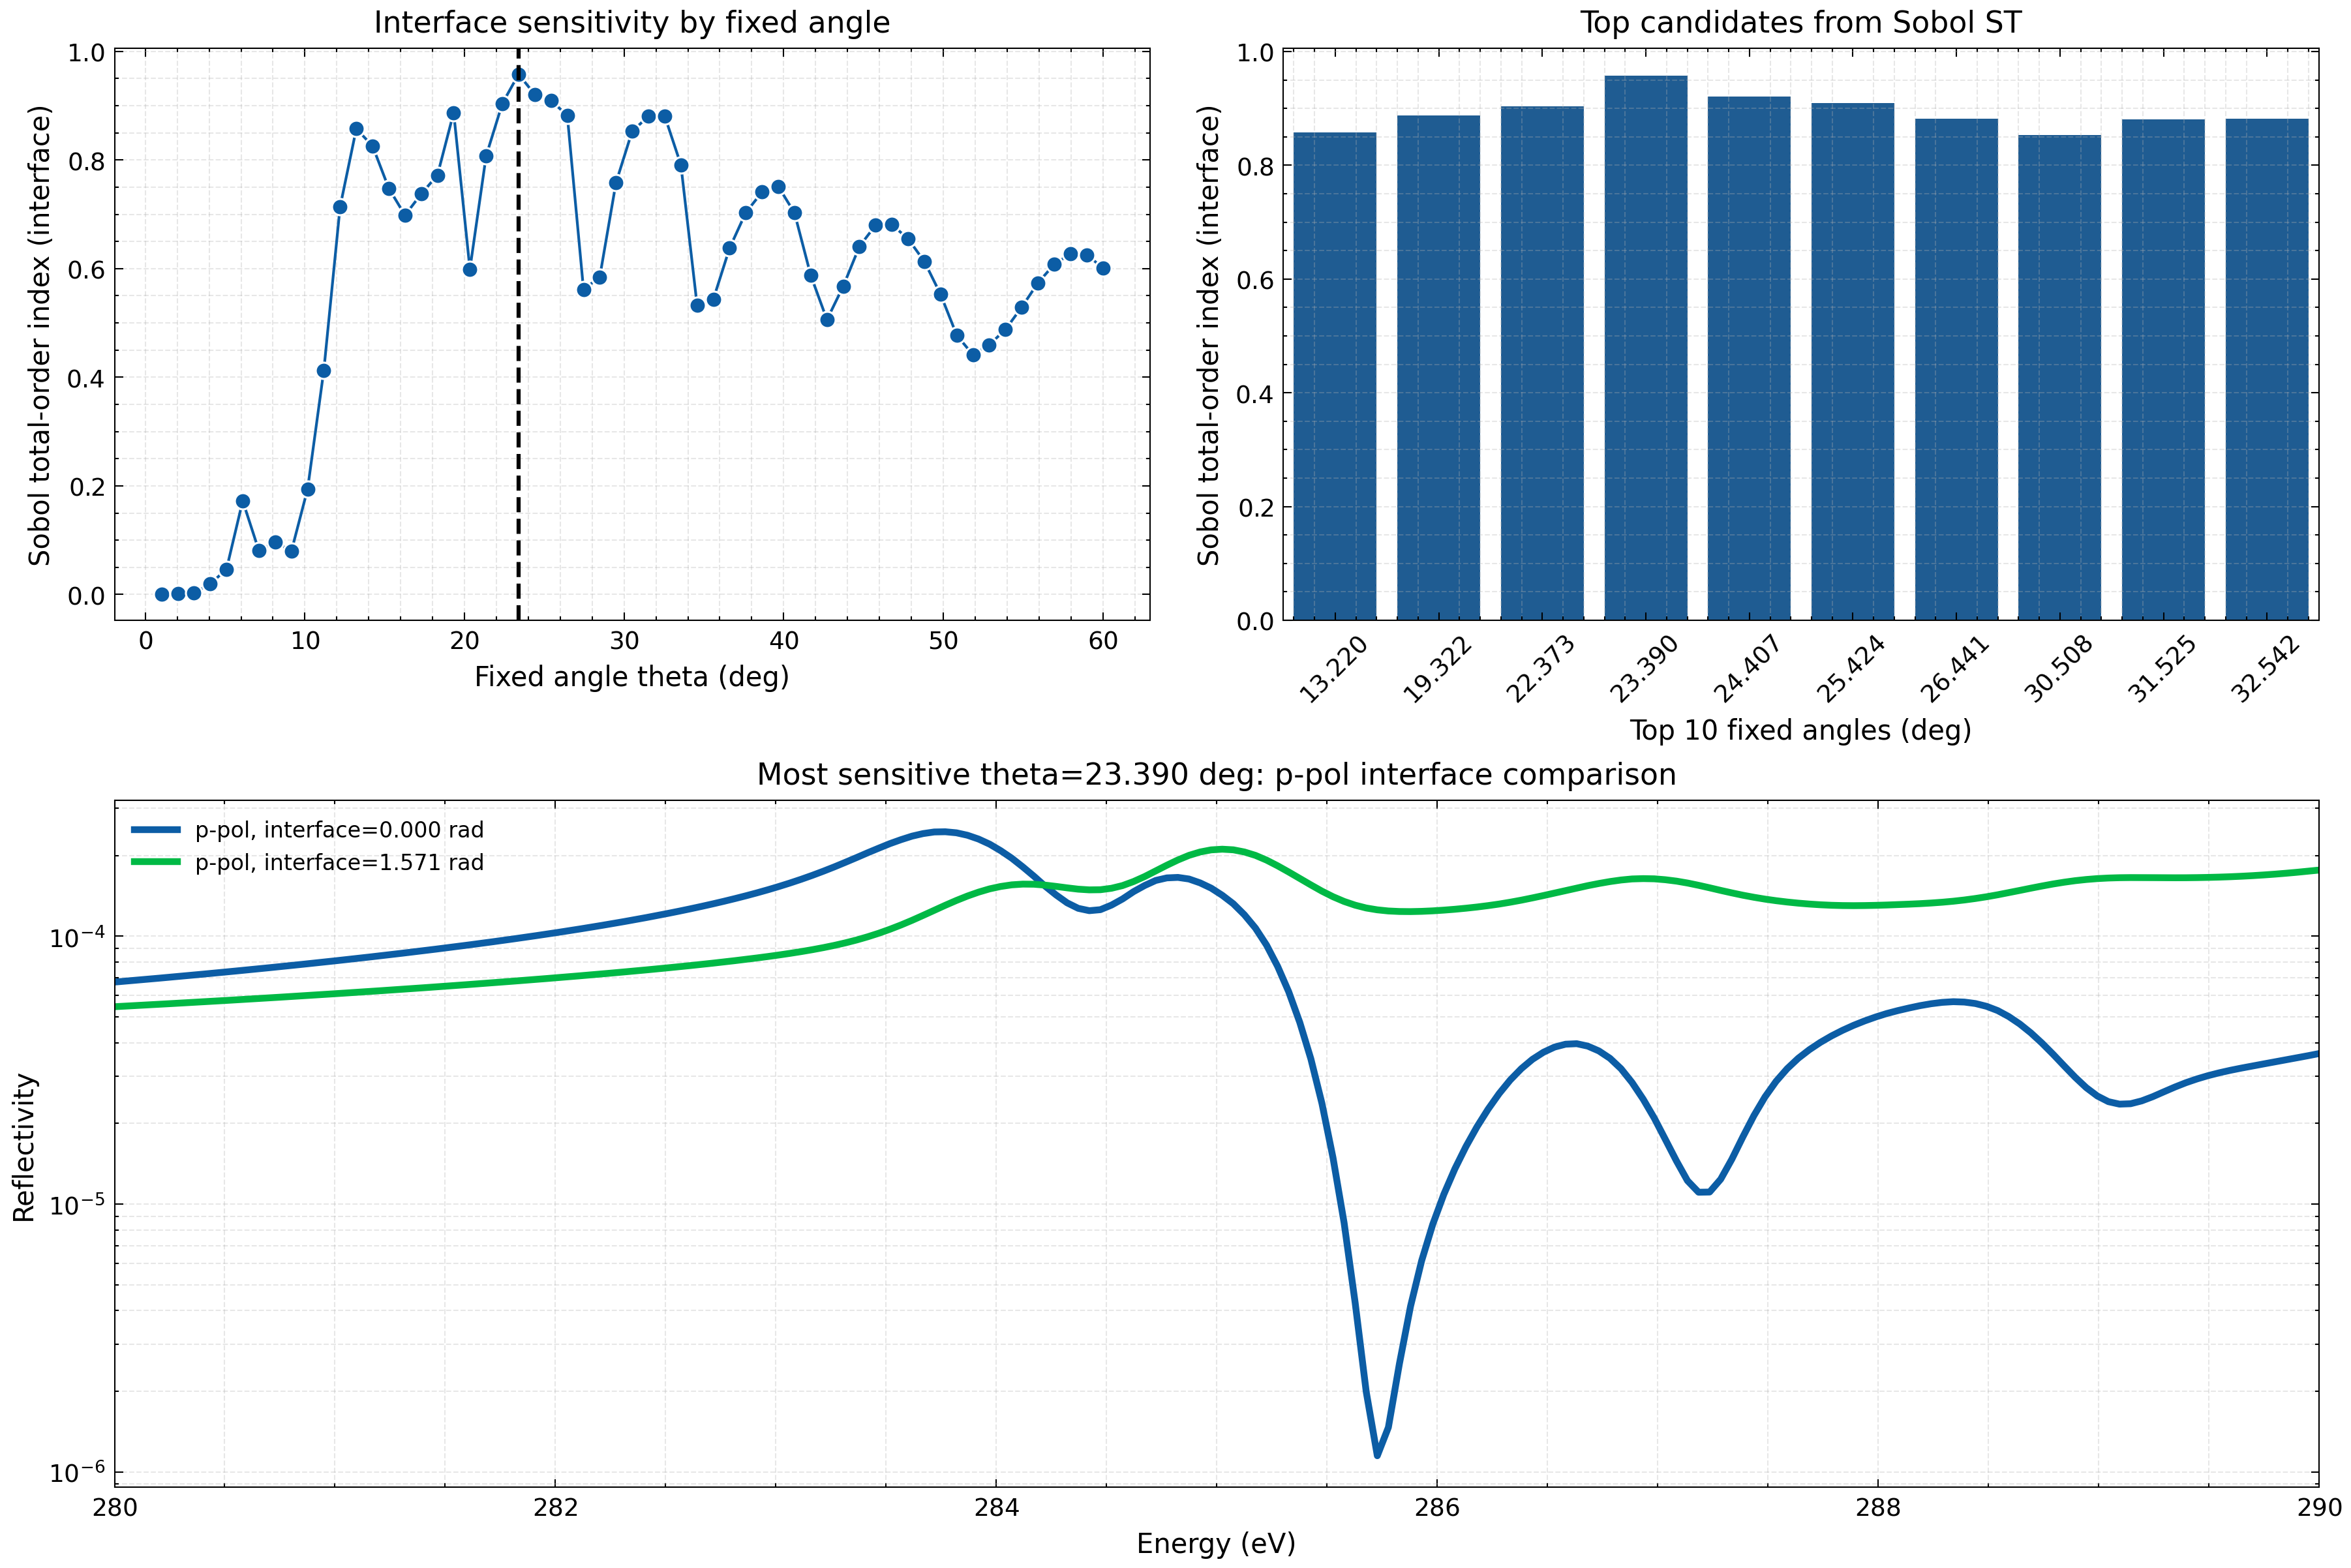

In [87]:
# SALib-based Morris+Sobol workflow
from SALib.analyze import morris as morris_analyze
from SALib.analyze import sobol as sobol_analyze
from SALib.sample import morris as morris_sample
from SALib.sample import sobol as sobol_sample
from scipy.interpolate import RegularGridInterpolator

if "anisotropy_cube" not in globals():
    anisotropy_cube = (s_data_all - p_data_all) / (s_data_all + p_data_all + 1e-12)

expected_shape = (theta.size, interfaces.size, energies.size)
if anisotropy_cube.shape != expected_shape:
    raise ValueError(f"Expected anisotropy_cube shape {expected_shape}, got {anisotropy_cube.shape}")

problem = {
    "num_vars": 2,
    "names": ["interface_rad", "energy_ev"],
    "bounds": [[float(interfaces.min()), float(interfaces.max())], [float(energies.min()), float(energies.max())]],
}

morris_n = 256
morris_levels = 8
morris_trajectories = 16
sobol_n = 1024
seed = 42

morris_design = morris_sample.sample(
    problem,
    N=morris_n,
    num_levels=morris_levels,
    optimal_trajectories=morris_trajectories,
    seed=seed,
)

sobol_design = sobol_sample.sample(
    problem,
    N=sobol_n,
    calc_second_order=False,
    seed=seed,
)

rows = []
for theta_idx, theta_deg in enumerate(theta):
    signal_slice = anisotropy_cube[theta_idx, :, :]
    interpolator = RegularGridInterpolator(
        points=(interfaces, energies),
        values=signal_slice,
        method="linear",
        bounds_error=False,
        fill_value=None,
    )

    y_morris = interpolator(morris_design)
    morris_stats = morris_analyze.analyze(
        problem,
        morris_design,
        y_morris,
        num_levels=morris_levels,
        seed=seed,
    )

    y_sobol = interpolator(sobol_design)
    sobol_stats = sobol_analyze.analyze(
        problem,
        y_sobol,
        calc_second_order=False,
        print_to_console=False,
    )

    rows.append(
        {
            "theta_deg": float(np.round(theta_deg, 3)),
            "morris_mu_star_interface": float(morris_stats["mu_star"][0]),
            "morris_sigma_interface": float(morris_stats["sigma"][0]),
            "morris_mu_star_energy": float(morris_stats["mu_star"][1]),
            "sobol_s1_interface": float(sobol_stats["S1"][0]),
            "sobol_st_interface": float(sobol_stats["ST"][0]),
            "sobol_s1_energy": float(sobol_stats["S1"][1]),
            "sobol_st_energy": float(sobol_stats["ST"][1]),
        }
    )

salib_df = pd.DataFrame(rows).sort_values("sobol_st_interface", ascending=False).reset_index(drop=True)
salib_df["rank_by_sobol_st_interface"] = np.arange(1, salib_df.shape[0] + 1)
salib_df["theta_label_deg"] = salib_df["theta_deg"].map(lambda x: f"{x:.3f}")

salib_path = output_dir / "fixed_angle_sensitivity_salib.parquet"
salib_df.to_parquet(salib_path, index=False)

print(f"saved: {salib_path}")
display(salib_df.head(10))

most_sensitive_theta = float(salib_df.iloc[0]["theta_deg"])
theta_idx = int(np.argmin(np.abs(theta - most_sensitive_theta)))
interface_idx_0 = int(np.argmin(np.abs(interfaces - 0.0)))
interface_idx_pi2 = int(np.argmin(np.abs(interfaces - (np.pi / 2))))

fig = plt.figure(figsize=(12, 8), constrained_layout=True)
grid = fig.add_gridspec(2, 2, height_ratios=[1, 1.2])
ax0 = fig.add_subplot(grid[0, 0])
ax1 = fig.add_subplot(grid[0, 1])
ax2 = fig.add_subplot(grid[1, :])

sns.lineplot(
    data=salib_df.sort_values("theta_deg"),
    x="theta_deg",
    y="sobol_st_interface",
    marker="o",
    ax=ax0,
)
ax0.set_xlabel("Fixed angle theta (deg)")
ax0.set_ylabel("Sobol total-order index (interface)")
ax0.set_title("Interface sensitivity by fixed angle")
ax0.grid(True)
ax0.axvline(theta[theta_idx], color="k", linestyle="--", linewidth=1.5)

top10_salib = salib_df.head(10).sort_values("theta_deg")
sns.barplot(
    data=top10_salib,
    x="theta_label_deg",
    y="sobol_st_interface",
    ax=ax1,
)
ax1.set_xlabel("Top 10 fixed angles (deg)")
ax1.set_ylabel("Sobol total-order index (interface)")
ax1.set_title("Top candidates from Sobol ST")
ax1.tick_params(axis="x", rotation=45)

ax2.plot(
    energies,
    p_data_all[theta_idx, interface_idx_0, :],
    lw=2.5,
    label="p-pol, interface=0.000 rad",
)
ax2.plot(
    energies,
    p_data_all[theta_idx, interface_idx_pi2, :],
    lw=2.5,
    label="p-pol, interface=1.571 rad",
)
ax2.set_xlabel("Energy (eV)")
ax2.set_ylabel("Reflectivity")
ax2.set_title(f"Most sensitive theta={theta[theta_idx]:.3f} deg: p-pol interface comparison")
ax2.set_yscale("log")
ax2.set_xlim(energies.min(), energies.max())
ax2.grid(True, which="both")
ax2.legend()

plt.show()
